# 02 — Spectral POD: separating structures by timescale

Standard POD ranks modes by energy and mixes all frequencies together. **SPOD** produces modes that are each coherent at a single frequency — so a nucleation site pulsing at 40 Hz shows up as *the* structure at 40 Hz, not blended into an energy-ranked blob.

The synthetic data below plants exactly that: a slow 5 Hz large-scale mode plus a localized site pulsing at 40 Hz.

In [1]:
import icarus as tf

In [2]:
import numpy as np

def make_boiling_like_data(ny=24, nx=30, nt=1500, dt=1e-3, seed=0):
    """Synthetic dataset that mimics a boiling IR recording:
    a slow large-scale mode + a localized 'nucleation site' pulsing at 40 Hz,
    with heat flux linearly coupled to temperature + irreducible noise."""
    rng = np.random.default_rng(seed)
    yy, xx = np.meshgrid(np.linspace(0, 1, nx), np.linspace(0, 1, ny))
    t = np.arange(nt) * dt

    slow_pattern = np.sin(np.pi * yy) * np.cos(np.pi * xx)
    slow = slow_pattern[:, :, None] * np.sin(2 * np.pi * 5 * t)

    site = np.exp(-(((yy - 0.7) ** 2 + (xx - 0.6) ** 2) / 0.01))
    site_pulse = site[:, :, None] * np.sin(2 * np.pi * 40 * t)

    T = 420.0 + 3.0 * slow + 1.5 * site_pulse         + 0.05 * rng.standard_normal((ny, nx, nt))
    q = 3.0e5 - 1.2e4 * (3.0 * slow) + 0.9e4 * (1.5 * site_pulse)         + 2.0e3 * rng.standard_normal((ny, nx, nt))
    return T, q, dt

T, q, dt = make_boiling_like_data()
print("T", T.shape, "| q", q.shape, "| dt", dt, "s")


T (24, 30, 1500) | q (24, 30, 1500) | dt 0.001 s


## 1. Fit SPOD straight from the field

`fit_field` handles cropping, mean-removal and flattening. `block_size` sets the frequency resolution vs statistical convergence trade-off (more/shorter blocks = smoother but coarser spectrum).

In [3]:
spod = tf.SPOD(n_modes=3, block_size=512).fit_field(
    T, dt=dt, spatial_crop=2)
print(f"{spod.n_blocks_} Welch blocks, "
      f"df = {spod.frequencies_[1]:.2f} Hz")

4 Welch blocks, df = 1.95 Hz


## 2. Where does coherent energy live?

Peaks in the spectrum are the dominant timescales.

dominant frequencies: [ 5.9 39.1] Hz


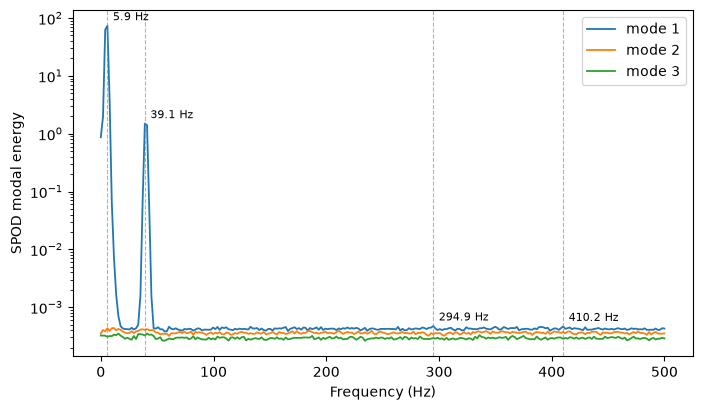

In [4]:
peaks = spod.dominant_frequencies(n=2)
print("dominant frequencies:", np.round(peaks, 1), "Hz")
spod.plot_spectrum();

## 3. What does each timescale look like?

The planted 40 Hz site appears as a compact bright spot; the 5 Hz mode is the large-scale pattern.

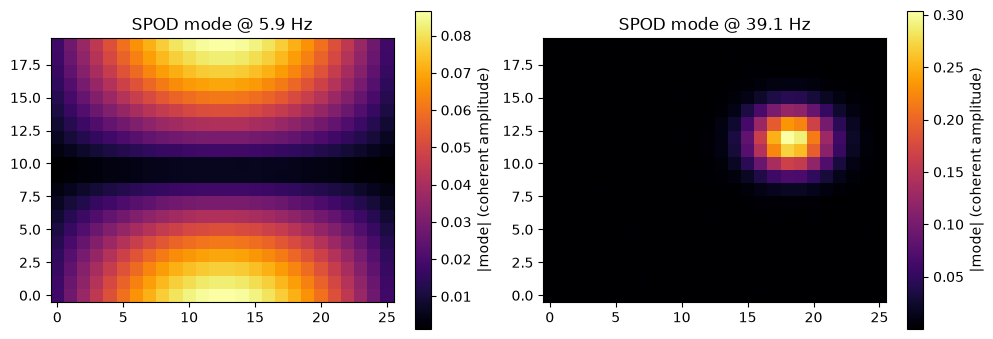

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, f0 in zip(axes, sorted(peaks)):
    spod.plot_mode(f0, ax=ax)
plt.tight_layout()

SPOD can also propose **frequency band edges** for partition-based modelling (used in tutorial 03): boundaries are placed in the energy valleys between peaks.

In [6]:
edges = spod.suggest_band_edges(n_bands=2)
print("suggested band edge(s):", np.round(edges, 1), "Hz")

suggested band edge(s): [29.3] Hz


Next: [03 — Band-wise prediction with uncertainty](03_bandwise_uncertainty.ipynb).

---
**Reference:** the SPOD method implemented here follows Towne, A., Schmidt, O. T. & Colonius, T. (2018), "Spectral proper orthogonal decomposition and its relationship to dynamic mode decomposition and resolvent analysis", *J. Fluid Mech.* **847**, 821-867 ([arXiv:1708.04393](https://arxiv.org/abs/1708.04393)). Spectral POD itself goes back to Lumley (1970), *Stochastic Tools in Turbulence*.